# Endogenous Investment via Capital — a Cobb-Douglas Supply Core

**Research direction.** Extend Teglio (2024) so that **investment drives output
*through capital*** — capital accumulation endogenises the *supply* side.

This notebook studies a stock-flow-consistent (SFC) core with:

* **True Cobb-Douglas production** `Y* = A·K^alpha·L^(1-alpha)` (`alpha = 1/3`),
  with **essential capital** (`K = 0 => Y* = 0`) and `Y = min(demand, Y*)`.
* **Distributive coherence**: `markup = alpha/(1-alpha)` so the wage share fixed
  by pricing equals the labour elasticity, `1/(1+markup) = 1-alpha = 0.667`.
* **Internal financing via retained earnings**: firms invest
  `I = clip(rho·profit·util_effect, floor, profit)`, retain *exactly* what they
  invest and distribute the rest as dividends. The firm cash account is an
  **intra-period pass-through that returns to zero** — no money sequestration.

The headline experiment sweeps the **retention ratio `rho`** (from the
low-capital baseline `rho = 0` to `rho = 0.40`).

> **Interpretive frame (read this before the results).** This core is
> **capacity-constrained everywhere** (u ~ 1 across the whole sweep, baseline
> included). The `rho = 0` baseline is *not* weak-demand stagnation — it is a
> **low-capital** economy where `K` settles where `delta·K = investment_floor`.
> The headline result "investment drives output" is therefore a **supply-side
> result** (capital raising capacity), not a Keynesian demand story: the demand
> channel is **dormant** here. The demand calibration (`c0 = 1.0`,
> `wealth_effect = 0.08`) was chosen to place the economy in the
> capacity-constrained regime, not estimated from data. Endogenising *demand as
> well* is the labour-market task (roadmap point 11), where slack becomes
> unemployment.


In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from model import MacroModel
from experiment import run_experiment, summarize, retention_sweep

sns.set_theme(style="ticks", context="paper", font_scale=1.2)

STEPS = 2000
SEEDS = 3
BASELINE_RHO = 0.0
EXTENDED_RHO = 0.40
RETENTIONS = [0.0, 0.20, 0.35, 0.40]

C_BASE, C_EXT = "#3b6fb5", "#d1662a"


C:\Users\recursivechaos\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Baseline (low capital) vs. extended (rho = 0.40)

Lines are the mean across seeds; shaded bands are the 95% confidence interval.
Note that utilisation stays near 1 in **both** scenarios (capacity-constrained
throughout) — the difference is the *level of capital*, hence of capacity.


In [2]:
baseline_panel = run_experiment(BASELINE_RHO, steps=STEPS, seeds=SEEDS)
extended_panel = run_experiment(EXTENDED_RHO, steps=STEPS, seeds=SEEDS)

baseline = summarize(baseline_panel)
extended = summarize(extended_panel)

# derived K/Y ratio of means
for s in (baseline, extended):
    s["KoverY_mean"] = s["Total_Capital_mean"] / s["Output_mean"]

print("Baseline  rho=0.00 : Y=%.1f  K=%.1f  u=%.2f" % (
    baseline["Output_mean"].iloc[-1], baseline["Total_Capital_mean"].iloc[-1],
    baseline["Average_Utilization_mean"].iloc[-1]))
print("Extended  rho=0.40 : Y=%.1f  K=%.1f  u=%.2f" % (
    extended["Output_mean"].iloc[-1], extended["Total_Capital_mean"].iloc[-1],
    extended["Average_Utilization_mean"].iloc[-1]))


C:\Users\recursivechaos\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


Baseline  rho=0.00 : Y=44.1  K=8.6  u=1.00
Extended  rho=0.40 : Y=157.3  K=405.2  u=0.99


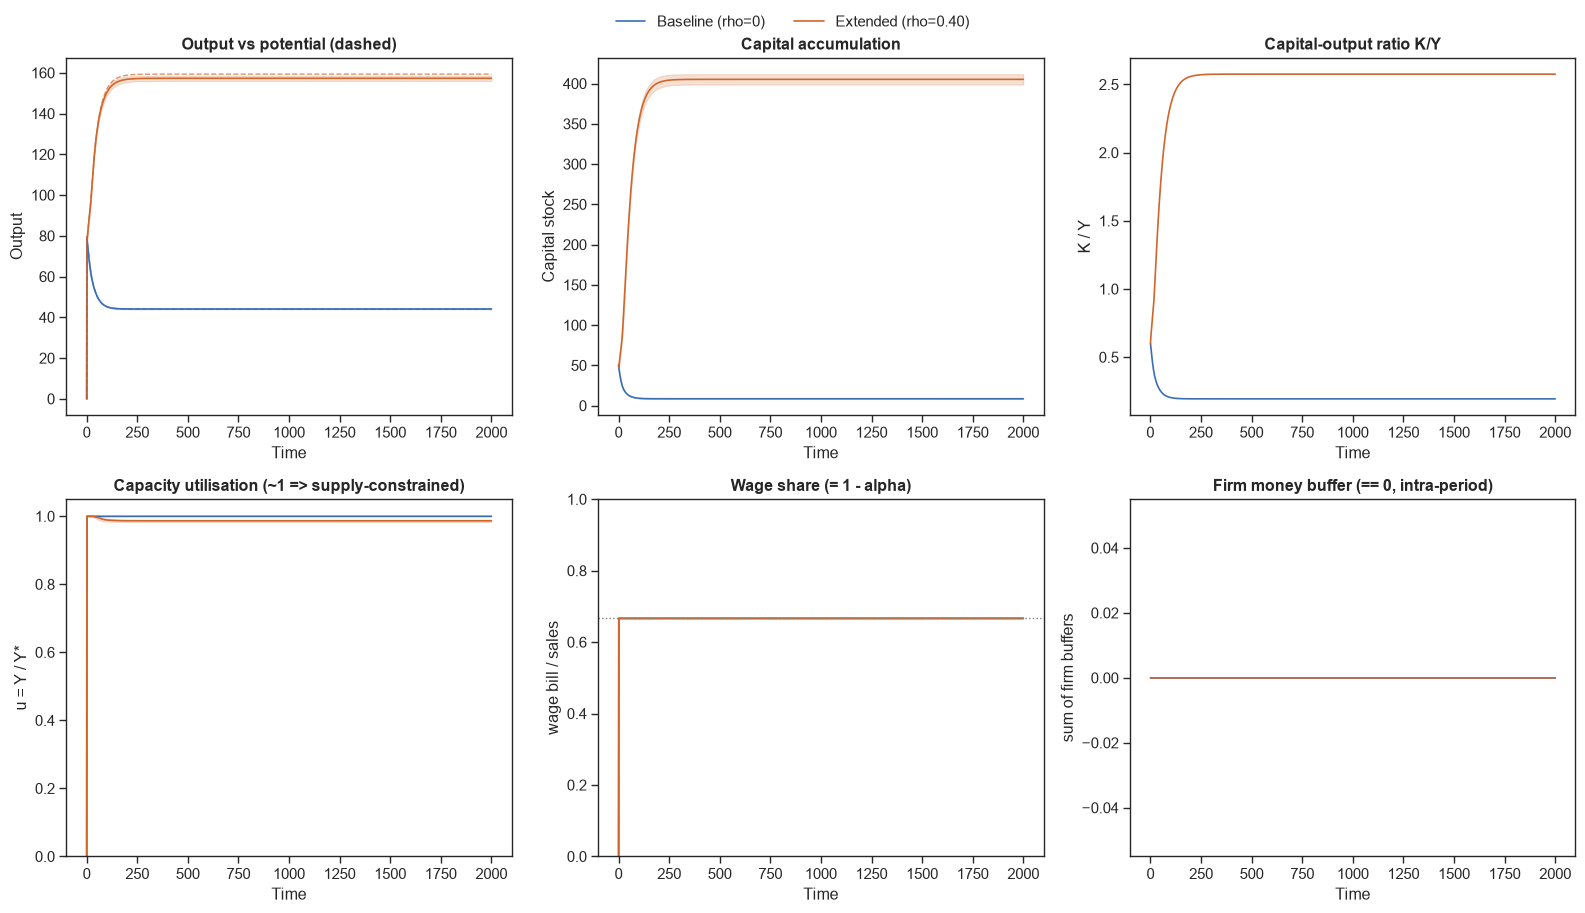

In [3]:
def band(ax, summ, col, label, color):
    t = summ.index
    ax.plot(t, summ[f"{col}_mean"], label=label, color=color)
    ax.fill_between(t, summ[f"{col}_lo"], summ[f"{col}_hi"], color=color, alpha=0.20)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Output vs potential (dashed)
ax = axes[0, 0]
band(ax, baseline, "Output", "Baseline (rho=0)", C_BASE)
band(ax, extended, "Output", "Extended (rho=0.40)", C_EXT)
ax.plot(baseline.index, baseline["Potential_Output_mean"], ls="--", lw=1, color=C_BASE, alpha=0.7)
ax.plot(extended.index, extended["Potential_Output_mean"], ls="--", lw=1, color=C_EXT, alpha=0.7)
ax.set_title("Output vs potential (dashed)", weight="bold")
ax.set_xlabel("Time"); ax.set_ylabel("Output"); ax.legend()

# Capital
ax = axes[0, 1]
band(ax, baseline, "Total_Capital", "Baseline", C_BASE)
band(ax, extended, "Total_Capital", "Extended", C_EXT)
ax.set_title("Capital accumulation", weight="bold")
ax.set_xlabel("Time"); ax.set_ylabel("Capital stock")

# K / Y
ax = axes[0, 2]
ax.plot(baseline.index, baseline["KoverY_mean"], color=C_BASE, label="Baseline")
ax.plot(extended.index, extended["KoverY_mean"], color=C_EXT, label="Extended")
ax.set_title("Capital-output ratio K/Y", weight="bold")
ax.set_xlabel("Time"); ax.set_ylabel("K / Y")

# Utilisation (both ~1: capacity-constrained)
ax = axes[1, 0]
band(ax, baseline, "Average_Utilization", "Baseline", C_BASE)
band(ax, extended, "Average_Utilization", "Extended", C_EXT)
ax.set_title("Capacity utilisation (~1 => supply-constrained)", weight="bold")
ax.set_xlabel("Time"); ax.set_ylabel("u = Y / Y*"); ax.set_ylim(0, 1.05)

# Wage share (0.667 by construction)
ax = axes[1, 1]
band(ax, baseline, "Wage_Share", "Baseline", C_BASE)
band(ax, extended, "Wage_Share", "Extended", C_EXT)
ax.axhline(2/3, ls=":", color="grey", lw=1)
ax.set_title("Wage share (= 1 - alpha)", weight="bold")
ax.set_xlabel("Time"); ax.set_ylabel("wage bill / sales"); ax.set_ylim(0, 1)

# Money buffer (identically 0: no sequestration)
ax = axes[1, 2]
band(ax, baseline, "Money_Buffer", "Baseline", C_BASE)
band(ax, extended, "Money_Buffer", "Extended", C_EXT)
ax.set_title("Firm money buffer (== 0, intra-period)", weight="bold")
ax.set_xlabel("Time"); ax.set_ylabel("sum of firm buffers")

handles, labels = axes[0, 0].get_legend_handles_labels()
for ax in axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.savefig(os.path.join('..', 'macro_results.png'), dpi=200, bbox_inches="tight")
plt.show()


## 2. Sweep over the retention ratio `rho`

As `rho` rises, firms retain and invest more of their profit, capital accumulates,
and steady-state output rises. `K/Y` tracks the analytical relation `rho·alpha/delta`
and `I/Y` tracks `rho·alpha`; the factor shares stay pinned at `1-alpha` / `alpha`
and the money buffer stays identically zero.


In [4]:
sweep = retention_sweep(RETENTIONS, steps=STEPS, seeds=SEEDS, tail=50)
sweep_display = sweep.rename(columns={
    "retention_ratio": "rho", "K_over_Y": "K/Y", "I_over_Y": "I/Y"})
sweep_display.round(3)


C:\Users\recursivechaos\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


,rho,Y,u,K/Y,I/Y,Wage_Share,Profit_Share,Total_Capital,Money_Buffer
0,0.00,44.100,1.000,0.194,0.010,0.667,0.333,8.577,0.0
1,0.20,106.076,0.998,1.131,0.057,0.667,0.333,119.961,0.0
2,0.35,146.616,0.988,2.228,0.111,0.667,0.333,326.593,0.0
3,0.40,157.319,0.987,2.576,0.129,0.667,0.333,405.235,0.0


C:\Users\recursivechaos\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


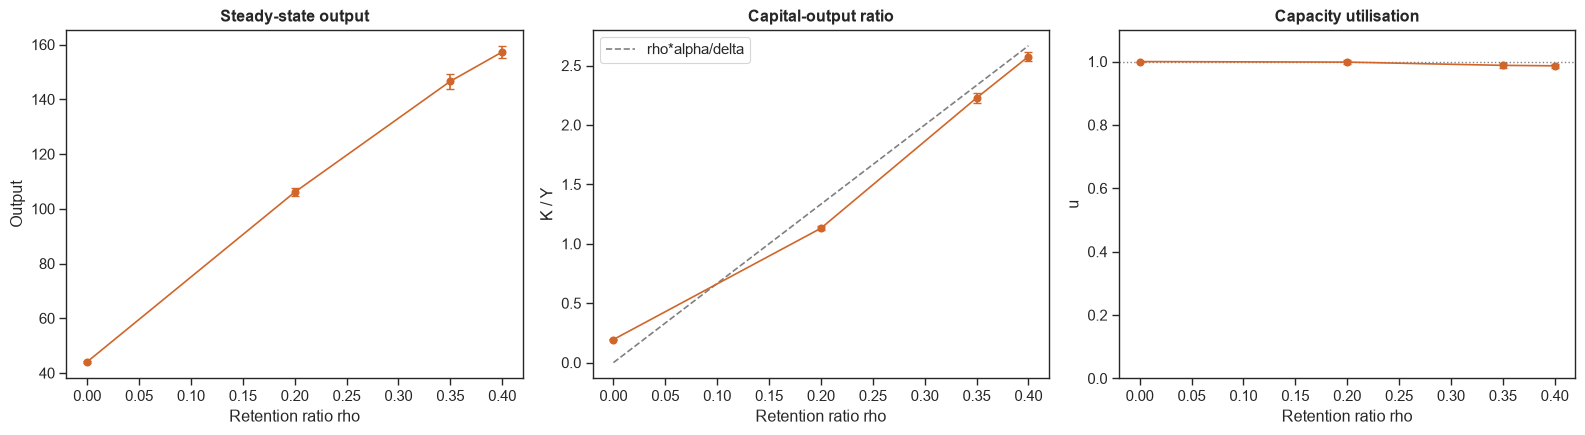

In [5]:
# per-seed steady values for confidence bands on the sweep
def sweep_with_ci(retentions, steps=STEPS, seeds=SEEDS, tail=50):
    rows = []
    for rho in retentions:
        panel = run_experiment(rho, steps=steps, seeds=seeds)
        steady = panel[panel.index >= steps - tail]
        per_seed = steady.groupby("Seed").mean(numeric_only=True)
        ky = per_seed["Total_Capital"] / per_seed["Output"]
        rows.append({
            "rho": rho,
            "Y_mean": per_seed["Output"].mean(), "Y_std": per_seed["Output"].std(ddof=1),
            "KY_mean": ky.mean(), "KY_std": ky.std(ddof=1),
            "u_mean": per_seed["Average_Utilization"].mean(),
            "u_std": per_seed["Average_Utilization"].std(ddof=1),
        })
    return pd.DataFrame(rows)

ci = sweep_with_ci(RETENTIONS)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].errorbar(ci["rho"], ci["Y_mean"], yerr=1.96*ci["Y_std"], fmt="o-", color=C_EXT, capsize=3)
axes[0].set_title("Steady-state output", weight="bold")
axes[0].set_xlabel("Retention ratio rho"); axes[0].set_ylabel("Output")

axes[1].errorbar(ci["rho"], ci["KY_mean"], yerr=1.96*ci["KY_std"], fmt="o-", color=C_EXT, capsize=3)
axes[1].plot(ci["rho"], ci["rho"]*(1/3)/0.05, ls="--", color="grey", label="rho*alpha/delta")
axes[1].set_title("Capital-output ratio", weight="bold")
axes[1].set_xlabel("Retention ratio rho"); axes[1].set_ylabel("K / Y"); axes[1].legend()

axes[2].errorbar(ci["rho"], ci["u_mean"], yerr=1.96*ci["u_std"], fmt="o-", color=C_EXT, capsize=3)
axes[2].axhline(1.0, ls=":", color="grey", lw=1)
axes[2].set_title("Capacity utilisation", weight="bold")
axes[2].set_xlabel("Retention ratio rho"); axes[2].set_ylabel("u"); axes[2].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(os.path.join('..', 'retention_sweep.png'), dpi=200, bbox_inches="tight")
plt.show()


## 3. The supply channel, made explicit

The claim is that output rises *because capital raises capacity*, not through a
demand multiplier. Since the economy is capacity-constrained (u ~ 1), actual
output sits on the Cobb-Douglas capacity curve: plotting steady-state `Y` and
potential `Y*` against the capital stock, the two coincide, and both rise with
`K` along `A·K^alpha·L^(1-alpha)`.


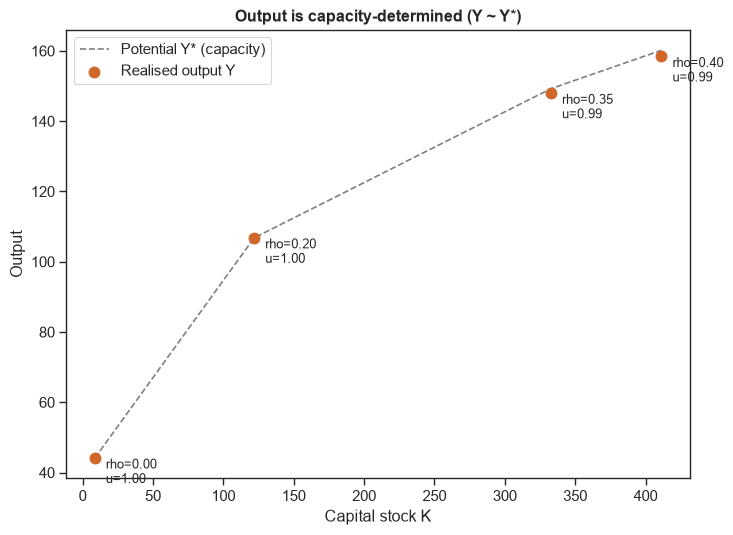

 rho       K       Y   Ystar     u  Y_over_Ystar
0.00   8.598  44.137  44.137 1.000         1.000
0.20 121.835 106.805 106.805 1.000         1.000
0.35 332.760 147.936 149.269 0.991         0.991
0.40 411.258 158.416 160.185 0.989         0.989


In [6]:
pts = []
for rho in RETENTIONS:
    m = MacroModel(retention_ratio=rho, seed=0)
    for _ in range(STEPS):
        m.step()
    d = m.datacollector.get_model_vars_dataframe().tail(50).mean()
    pts.append((rho, d["Total_Capital"], d["Output"], d["Potential_Output"],
                d["Average_Utilization"]))
pts = pd.DataFrame(pts, columns=["rho", "K", "Y", "Ystar", "u"])

fig, ax = plt.subplots(figsize=(7.5, 5.5))
order = pts.sort_values("K")
ax.plot(order["K"], order["Ystar"], "--", color="grey", label="Potential Y* (capacity)")
ax.scatter(pts["K"], pts["Y"], s=60, color=C_EXT, zorder=3, label="Realised output Y")
for _, r in pts.iterrows():
    ax.annotate(f"rho={r['rho']:.2f}\nu={r['u']:.2f}", (r["K"], r["Y"]),
                textcoords="offset points", xytext=(8, -18), fontsize=9)
ax.set_title("Output is capacity-determined (Y ~ Y*)", weight="bold")
ax.set_xlabel("Capital stock K"); ax.set_ylabel("Output")
ax.legend()
plt.tight_layout()
plt.show()

print((pts.assign(Y_over_Ystar=pts["Y"]/pts["Ystar"])
          [["rho","K","Y","Ystar","u","Y_over_Ystar"]].round(3)).to_string(index=False))


## 4. Reading of the results

* **Investment drives output via capital.** Raising `rho` from 0 to 0.40 takes
  capital from a low floor to a large stock and output from ~44 to ~157. Because
  `u ~ 1` throughout, `Y ~ Y* = A·K^alpha·L^(1-alpha)`: the output gain is the
  **capacity** expanding with capital — a supply-side result.
* **Distribution is coherent and exact.** The wage share sits at `1-alpha = 0.667`
  and the profit share at `alpha = 0.333` by construction (`markup = alpha/(1-alpha)`).
* **The accounting is clean.** `K/Y` matches `rho·alpha/delta` and `I/Y` matches
  `rho·alpha`; the firm money buffer is identically zero every period (retained
  earnings are invested or paid out, never sequestered), and money is conserved.
* **What this core is *not*.** It is capacity-constrained everywhere; the `rho=0`
  baseline is a low-capital economy, not weak-demand stagnation. The Keynesian
  demand channel is dormant here by design. It becomes active at the labour-market
  stage (roadmap point 11), where slack turns into unemployment.

Parameters (`alpha = 1/3`, `retention_ratio`, `delta = 0.05`, `c0 = 1.0`,
`wealth_effect = 0.08`, `investment_floor`, `beta`, `target_utilization = 0.90`)
are standard or chosen-for-regime values, **not yet empirically anchored** — the
bibliographic anchoring is a later task.
